# R4_External_Lab_Validation_Accuracy      | Jayant Ojha

In [318]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity='all'

In [319]:
#Import importatnt libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Read the input file and check the data dimension

In [320]:
credit_df = pd.read_csv('./german_credit.csv')

In [321]:
credit_df.shape

(1000, 21)

In [322]:
#observe some 5 random rows of this data, to get a visual-feel
#of different possible values
credit_df.sample(n=5, random_state=5)

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
544,0,no checking account,12,critical account/ other credits existing (not ...,car (new),1255,... < 100 DM,.. >= 7 years,4,male : single,...,4,real estate,61,none,own,2,unskilled - resident,1,none,yes
515,0,< 0 DM,6,critical account/ other credits existing (not ...,car (new),609,... < 100 DM,4 <= ... < 7 years,4,female : divorced/separated/married,...,3,if not A121 : building society savings agreeme...,37,none,own,2,skilled employee / official,1,none,no
193,0,no checking account,6,existing credits paid back duly till now,domestic appliances,2108,... < 100 DM,4 <= ... < 7 years,2,male : married/widowed,...,2,real estate,29,none,rent,1,skilled employee / official,1,none,yes
11,1,< 0 DM,48,existing credits paid back duly till now,business,4308,... < 100 DM,... < 1 year,3,female : divorced/separated/married,...,4,if not A121 : building society savings agreeme...,24,none,rent,1,skilled employee / official,1,none,yes
279,0,no checking account,24,existing credits paid back duly till now,domestic appliances,1901,100 <= ... < 500 DM,1 <= ... < 4 years,4,male : single,...,4,"if not A121/A122 : car or other, not in attrib...",29,none,rent,1,management/ self-employed/ highly qualified em...,1,"yes, registered under the customers name",yes


In [323]:
#Based on the *.info(), as given below, there are no "null" values
#the *.describe() can be further check on the min, max, mean etc 
#descriptive stats for diferent features
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

In [324]:
credit_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
default,"1,000.00",NaN,NaN,NaN,0.30,0.46,0.00,0.00,0.00,1.00,1.00
account_check_status,1000,4,no checking account,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_in_month,"1,000.00",NaN,NaN,NaN,20.90,12.06,4.00,12.00,18.00,24.00,72.00
credit_history,1000,5,existing credits paid back duly till now,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,1000,10,domestic appliances,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_amount,"1,000.00",NaN,NaN,NaN,"3,271.26","2,822.74",250.00,"1,365.50","2,319.50","3,972.25","18,424.00"
savings,1000,5,... < 100 DM,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
present_emp_since,1000,5,1 <= ... < 4 years,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
installment_as_income_perc,"1,000.00",NaN,NaN,NaN,2.97,1.12,1.00,2.00,3.00,4.00,4.00
personal_status_sex,1000,4,male : single,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [325]:
# You can access from https://www.kaggle.com/uciml/german-credit
#Read input file and understand the data
# "default" is my dependent variable

### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [326]:
#Before we think of splitting the data
#saving the dataframe copy
orig_credit_df = credit_df.copy()

In [327]:
orig_credit_df.head()

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


In [328]:
# splitting data into training and test set for independent attributes
from sklearn.model_selection import train_test_split

X =  credit_df.drop("default", axis=1)
y =  credit_df.pop("default")
train_set, test_set, train_labels, test_labels = train_test_split(X, y, test_size=0.50, random_state=2)


In [329]:
#we will validate the split % by loking at the shapes of the split portions
train_set.shape
test_set.shape
train_labels.shape
test_labels.shape

(500, 20)

(500, 20)

(500,)

(500,)

In [330]:
train_set.head()

,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,other_debtors,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
281,no checking account,12,existing credits paid back duly till now,radio/television,1574,... < 100 DM,1 <= ... < 4 years,4,male : single,none,2,real estate,50,none,own,1,skilled employee / official,1,none,yes
35,0 <= ... < 200 DM,45,critical account/ other credits existing (not ...,domestic appliances,4746,... < 100 DM,... < 1 year,4,male : single,none,2,if not A121 : building society savings agreeme...,25,none,own,2,unskilled - resident,1,none,yes
968,no checking account,42,existing credits paid back duly till now,domestic appliances,7166,unknown/ no savings account,4 <= ... < 7 years,2,male : married/widowed,none,4,if not A121 : building society savings agreeme...,29,none,rent,1,skilled employee / official,1,"yes, registered under the customers name",yes
813,< 0 DM,48,existing credits paid back duly till now,repairs,3051,... < 100 DM,1 <= ... < 4 years,3,male : single,none,4,"if not A121/A122 : car or other, not in attrib...",54,none,own,1,skilled employee / official,1,none,yes
743,< 0 DM,24,all credits at this bank paid back duly,radio/television,2483,500 <= ... < 1000 DM,1 <= ... < 4 years,4,male : single,none,4,real estate,22,stores,own,1,skilled employee / official,1,"yes, registered under the customers name",yes


In [331]:
# Lets build a Ensemble model but need to modify the dataset first


### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [332]:
#The drop_first=True, will make the shape go as (1000, 48)
#in place of the (1000,61)...in case the drop_first is not set to
#True
credit_df_new = pd.get_dummies(orig_credit_df, drop_first = True)
#credit_df_new = pd.get_dummies(orig_credit_df)

In [333]:
#Before we think of splitting the data
#saving the dataframe copy again (after the latest get_dummies)
orig_credit_df_new = credit_df_new.copy()

In [334]:
orig_credit_df_new.head()

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance,account_check_status_< 0 DM,account_check_status_>= 200 DM / salary assignments for at least 1 year,...,property_unknown / no property,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,"telephone_yes, registered under the customers name",foreign_worker_yes
0,0,6,1169,4,4,67,2,1,1,0,...,0,1,0,1,0,1,0,0,1,1
1,1,48,5951,2,2,22,1,1,0,0,...,0,1,0,1,0,1,0,0,0,1
2,0,12,2096,2,3,49,1,2,0,0,...,0,1,0,1,0,0,0,1,0,1
3,0,42,7882,2,4,45,1,2,1,0,...,0,1,0,0,0,1,0,0,0,1
4,1,24,4870,3,4,53,2,2,1,0,...,1,1,0,0,0,1,0,0,0,1


In [335]:
credit_df_new.shape

(1000, 49)

In [336]:
credit_df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 49 columns):
default                                                                       1000 non-null int64
duration_in_month                                                             1000 non-null int64
credit_amount                                                                 1000 non-null int64
installment_as_income_perc                                                    1000 non-null int64
present_res_since                                                             1000 non-null int64
age                                                                           1000 non-null int64
credits_this_bank                                                             1000 non-null int64
people_under_maintenance                                                      1000 non-null int64
account_check_status_< 0 DM                                                   1000 non-null uint8
account_chec

In [337]:
# splitting data into training and test set for independent attributes
from sklearn.model_selection import train_test_split

X =  credit_df_new.drop("default", axis=1)
y =  credit_df_new.pop("default")
train_set, test_set, train_labels, test_labels = train_test_split(X, y, test_size=0.50, random_state=2)

In [338]:
# Print Shape of model data
train_set.shape
test_set.shape
train_labels.shape
test_labels.shape

(500, 48)

(500, 48)

(500,)

(500,)

### Check for highly correlated variables but don't required any treatment for this use case

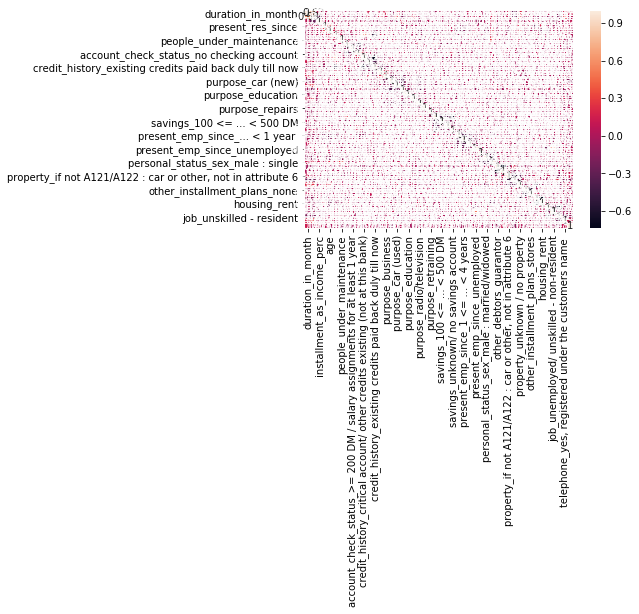

In [339]:
#will look at the corr-matrix heatmap for this
#But as the features are too many, we actually can't make use of
#the below visual matrix, hence will depend on the upcoming
#code to find out the high correlation features if any
sns.heatmap(credit_df_new.corr(), annot=True)

In [340]:
# Create correlation matrix with all strongly correlated values (i.e. both -ve and +ve
# values converted to absolute counterparts so as to compare with a thresold like 0.95)
corr_matrix = credit_df_new.corr().abs()
#Now using the Datframe.where() method, we replace all the elements of this corr_matrix,
#which are "on-or-below" the main digonal to NaNs, while retaining the original absolute values
#on the "upper-triangle" of the correlation-matrix (i.e. only one set of value on upper or lower triangles
#represents all the possible correlation values)
upper= corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))
# Find index of feature columns with correlation greater than 0.95
#we get a "list" of features which can be dropped.
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(to_drop)

##The *empty* list tells us that there aren't any features which are "strongly correlated" with each other
#hence **none to drop**.

[]


### Drop the original variables which are converted to dummy

In [341]:
#The pd BIF: get_dummies(orig_credit_df, drop_first = True) has alerady achieved this purpose
#as is eveident from the cell above where: cred is displayed.it_df_new.info() is displayed.

### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [342]:
credit_df_new = orig_credit_df_new.copy()

In [343]:
# splitting data into training and test set for independent attributes
from sklearn.model_selection import train_test_split

X =  credit_df_new.drop("default", axis=1)
y =  credit_df_new.pop("default")
train_set, test_set, train_labels, test_labels = train_test_split(X, y, test_size=0.3, random_state=9999)

In [344]:
# Print Shape of model data
train_set.shape
test_set.shape
train_labels.shape
test_labels.shape

(700, 48)

(300, 48)

(700,)

(300,)

### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [345]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn import model_selection

In [346]:
#Bootstrapped sampled multiple decision tree(with the hope of controlling bias error)
Rf_model = RandomForestClassifier(criterion='entropy',random_state=0 )

In [347]:
#Perform Grid Search Method to find the optimal n_estimators  
from sklearn.model_selection import GridSearchCV
parameter={'n_estimators':np.arange(1,100)}
GS=GridSearchCV(Rf_model,parameter,cv=3)
GS.fit(X,y)

GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators='warn', n_jobs=None,
            oob_score=False, random_state=0, verbose=0, warm_start=False),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'n_estimators': array([ 1,  2, ..., 98, 99])},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [348]:
GS.best_params_

{'n_estimators': 81}

In [349]:
#Bootstrapped sampled multiple decision tree(with the hope of controlling bias error)
#with optimal n_estimators as above
Rf_model = RandomForestClassifier(criterion='entropy', n_estimators=81, random_state=0 )

In [350]:
Rf_model.fit(train_set, train_labels)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=81, n_jobs=None,
            oob_score=False, random_state=0, verbose=0, warm_start=False)

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [351]:
#The actual 1's and 0s in this split are as follows
#i.e. 47 1s and 12 0s
test_labels.value_counts()

0    210
1     90
Name: default, dtype: int64

In [352]:
y_pred=Rf_model.predict(test_set)   # performance on test data
acc=metrics.accuracy_score(test_labels,y_pred)
print(acc)

0.7666666666666667


In [353]:
cm=metrics.confusion_matrix(test_labels,y_pred)
print(cm)

[[197  13]
 [ 57  33]]


### Q6 Show the list of the features importance( 1 Marks)

In [354]:
# importance of features in the tree building ( The importance of a feature is computed as the 
#(normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print (pd.Series(Rf_model.feature_importances_,index = list(X)).sort_values(ascending=False))

credit_amount                                                                0.10
age                                                                          0.09
duration_in_month                                                            0.09
account_check_status_no checking account                                     0.06
present_res_since                                                            0.04
installment_as_income_perc                                                   0.04
account_check_status_< 0 DM                                                  0.03
other_installment_plans_none                                                 0.03
credit_history_critical account/ other credits existing (not at this bank)   0.02
credits_this_bank                                                            0.02
purpose_car (new)                                                            0.02
housing_own                                                                  0.02
personal_status_

### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [355]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc

In [356]:
# Use below values
num_folds = 10
seed = 77

In [357]:
#Validate the Random Forest model build above using k fold
models = []
models.append(('RandomForest', Rf_model))

In [358]:
names = []
pd.options.display.float_format = '{:,.2f}'.format
scoring = {'accuracy' : make_scorer(accuracy_score), 
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score), 
           'f1_score' : make_scorer(f1_score)}
for name, model in models:
	kfold = model_selection.KFold(n_splits=10,random_state=77)
	results = model_selection.cross_validate(model, X, y, cv=kfold, scoring=scoring)
	names.append(name)
	print("For {} model, test_accuracy-mean value: {} & test_accuracy-stdDev: {}".format(name,\
           round(np.mean(results['test_accuracy']), 2),\
           round(np.std(results['test_accuracy']),2)))
	print("For {} model, test_precision-mean value: {} & test_precision-stdDev: {}".format(name,\
           round(np.mean(results['test_precision']), 2),\
           round(np.std(results['test_precision']),2)))
	print("For {} model, test_recall-mean value: {} & test_recall-stdDev: {}".format(name,\
           round(np.mean(results['test_recall']), 2),\
           round(np.std(results['test_recall']),2)))                                                                       
	print("For {} model, test_f1_score-mean value: {} & test_f1_score-stdDev: {}".format(name,\
           round(np.mean(results['test_f1_score']), 2),\
           round(np.std(results['test_f1_score']),2)))        

For RandomForest model, test_accuracy-mean value: 0.76 & test_accuracy-stdDev: 0.06
For RandomForest model, test_precision-mean value: 0.7 & test_precision-stdDev: 0.12
For RandomForest model, test_recall-mean value: 0.39 & test_recall-stdDev: 0.12
For RandomForest model, test_f1_score-mean value: 0.49 & test_f1_score-stdDev: 0.12


#Calculate Mean & stdDev scores:

For RandomForest model:

test_accuracy-mean value: 0.76 & test_accuracy-stdDev: 0.06

test_precision-mean value: 0.7 & test_precision-stdDev: 0.12

test_recall-mean value: 0.39 & test_recall-stdDev: 0.12

test_f1_score-mean value: 0.49 & test_f1_score-stdDev: 0.12

In [359]:
pd.DataFrame.from_dict(results)[['test_accuracy', 'test_precision', 'test_recall', 'test_f1_score']]

,test_accuracy,test_precision,test_recall,test_f1_score
0,0.87,0.80,0.64,0.71
1,0.69,0.54,0.22,0.31
2,0.78,0.53,0.35,0.42
3,0.79,0.67,0.50,0.57
4,0.77,0.69,0.32,0.44
5,0.67,0.83,0.24,0.38
6,0.74,0.64,0.30,0.41
7,0.82,0.94,0.47,0.62
8,0.78,0.68,0.45,0.54
9,0.74,0.65,0.41,0.50


#Calculate Mean & stdDev scores: 

**For RandomForest model:**

**test_accuracy-mean value: 0.76 & 
test_accuracy-stdDev: 0.06**

**test_precision-mean value: 0.7 &
test_precision-stdDev: 0.12**

**test_recall-mean value: 0.39 &
test_recall-stdDev: 0.12**

**test_f1_score-mean value: 0.49 &
test_f1_score-stdDev: 0.12**

# Q8 Print the confusion matrix( 1 Marks)

In [360]:
#The actual 1's and 0s in this split are as follows
#i.e. 47 1s and 12 0s
test_labels.value_counts()

0    210
1     90
Name: default, dtype: int64

In [361]:
cm=metrics.confusion_matrix(test_labels,y_pred)
print(cm)

[[197  13]
 [ 57  33]]


In [362]:
#Here is the crosstab representation of the same
cm = pd.crosstab(test_labels, y_pred, rownames=['Actual'], colnames=['Predicted'], margins=True)
cm

Predicted,0,1,All
Actual,,,
0,197,13,210
1,57,33,90
All,254,46,300


# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [363]:
#recall in above case
33/90

0.36666666666666664

In [364]:
#precison in above case
33/46

0.717391304347826

# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [365]:
#Hint: Use roc_curve

In [366]:
y_predictProb = model.predict_proba(test_set)

In [367]:
fpr, tpr, thresholds = roc_curve(test_labels, y_predictProb[::,1])

In [368]:
roc_auc = auc(fpr, tpr)
roc_auc

0.7726455026455026

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'Receiver operating characteristic')

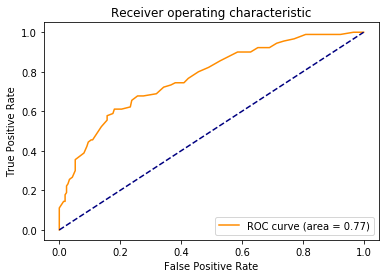

In [369]:
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

In [370]:
#ROC-AUC (area under the curve)
roc_auc

0.7726455026455026

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# End Of Ext Lab